In [100]:
import random

import pandas as pd
from pokerkit import *
from dotenv import load_dotenv
import json
from anthropic import Anthropic, beta_tool
from mediumterm import MediumTermMemory
from matplotlib import pyplot as plt
from matplotlib.patches import Patch
import numpy as np

In [101]:
load_dotenv()

client = Anthropic()

In [102]:
system_prompt = """You are a poker agent playing Texas Hold'em No-Limit. 
Blinds are 1000/2000. You are Player 1 (Hero). Player 2 is P2, Player 3 is P3 and so on. 
Think about pot odds, position, and hand strength before deciding. Make sure to carefully read and use the information in the provided json
Use the take_action tool to submit your decision."""

@beta_tool
def take_action(action: str, reasoning: str, amount: float = 0) -> str:
    """Submit your poker action for this turn and give a maximum 3 sentence explanation for why.

    Args:
        action: One of fold, check, call, raise
        amount: Raise amount in chips. Required if action is raise.
        reasoning: Reasoning for why you took a poker action. Maximum 3 sentences. Rate how aggressive each opponent's actions are on a 1-10 scale, but only if you made it to the flop or later. 
    """
    return json.dumps({"status": "accepted", "action": action, "amount": amount, 'reasoning': reasoning})

def run_turn(state_json):
    messages = [{
        "role": "user",
        "content": f"""It's your turn to act. Here is the current game state:
    
    ```json
    {state_json}
    ```
    
    Decide your action."""}]

    runner = client.beta.messages.tool_runner(
        model="claude-haiku-4-5-20251001",
        max_tokens=1024,
        tools=[take_action],
        system=system_prompt,
        messages=messages
    )

    agent_action = None

    for message in runner:
        tokens = f"Input: {message.usage.input_tokens}, Output: {message.usage.output_tokens}"

        for block in message.content:
            if block.type == "tool_use" and block.name == "take_action":
                agent_action = block.input

    return agent_action, tokens

def street_converter(index):
    if index == 0:
        return 'preflop'
    elif index == 1:
        return 'flop'
    elif index == 2:
        return 'turn'
    elif index == 3:
        return 'river'
    
def get_visible_operations(state):
    visible = []
    showdown = sum(1 for p in state.statuses if p) > 1
    for op in state.operations:
        if isinstance(op, ChipsPushing):
            winners = {i for i, amt in enumerate(op.amounts) if amt > 0}

    for op in state.operations:
        if isinstance(op, HoleDealing):
            if op.player_index == 0:
                visible.append(op)
            else:
                continue
        elif isinstance(op, CardBurning):
            continue
        elif isinstance(op, HoleCardsShowingOrMucking):
            if showdown or op.player_index in winners:
                visible.append(op)
        else:
            visible.append(op)
    return visible

judge_system_prompt = """You are an evaluating agent for players playing Texas Hold-em. Your job is to evaluate and provide useful information about the other non-agent players to aid Player 1 in defeating them. Do not evaluate Player 1 (Hero), focus on the other players. Remember that index 0 is the agent, index 1 is Player 2 and so on. Use the generate_observation tool to submit your decision."""

@beta_tool
def generate_observation(evaluation: str) -> str:
    """Evaluate the action history of the game in the previous poker hand. 

    Args:
        evaluation: The evaluation of how the other players played. Be specific as to any mistakes or good moves each non-Hero player made. 
    """
    return json.dumps({"status": "accepted", "evaluation": evaluation})

    
def run_observation_generator(action_history):
    eval_json = {'action_history': action_history}
    messages = [{
        "role": "user",
        "content": f"""Here is the action history of the game. 
    
    ```json
    {eval_json}
    ```
    
    Generate your observations."""}]

    runner = client.beta.messages.tool_runner(
        model="claude-haiku-4-5-20251001",
        max_tokens=1024,
        tools=[generate_observation],
        system=judge_system_prompt,
        messages=messages
    )

    agent_action = None

    for message in runner:
        for block in message.content:
            if block.type == "tool_use" and block.name == "generate_observation":
                agent_action = block.input["evaluation"]

    return agent_action


In [103]:
def pocket_pair_strategy(state, player_index):
    hole = state.hole_cards[player_index]
    is_pair = len(hole) >= 2 and hole[0].rank == hole[1].rank
    strong_pair_ranks = {"A", "K", "Q", "J", "T", "9", "8", "7"}
    is_strong_pair = is_pair and hole[0].rank in strong_pair_ranks
    if is_strong_pair and state.can_complete_bet_or_raise_to():
        min_raise = state.min_completion_betting_or_raising_to_amount
        max_raise = state.max_completion_betting_or_raising_to_amount
        target_raise = min(min_raise * 2, max_raise)
        state.complete_bet_or_raise_to(target_raise)
    elif is_pair and state.can_check_or_call():
        state.check_or_call()
    elif state.can_fold():
        state.fold()
    else:
        state.check_or_call()

def punter_strategy(state, player_index):
    punter_is_punting_this_hand = random.random() < 0.1
    if not punter_is_punting_this_hand:
        if state.can_fold():
            state.fold()
        else:
            state.check_or_call()
        return
    if state.can_complete_bet_or_raise_to():
        min_raise = state.min_completion_betting_or_raising_to_amount
        max_raise = state.max_completion_betting_or_raising_to_amount
        target_raise = min(min_raise * 2, max_raise)
        state.complete_bet_or_raise_to(target_raise)
    elif state.can_check_or_call():
        state.check_or_call()
    elif state.can_fold():
        state.fold()

def tight_passive_strategy(state, player_index):
    r = random.random()
    if r < 0.9 and state.can_fold():
        state.fold()
    elif state.can_check_or_call():
        state.check_or_call()
    elif state.can_fold():
        state.fold()

def random_raiser(state, player_index):
    action_rand = random.random()
    if action_rand < 0.1 and state.can_complete_bet_or_raise_to():
    # 10% chance to raise to 3x the big blind
        min_raise = state.min_completion_betting_or_raising_to_amount
        max_raise = state.max_completion_betting_or_raising_to_amount # All-in

    # Raise to 2x the minimum required to keep it moving
        target_raise = min(min_raise * 2, max_raise)
        state.complete_bet_or_raise_to(target_raise)
    elif action_rand < 0.2 and state.can_fold():
    # 10% chance to fold
        state.fold()
    else:
        state.check_or_call()

opponent_strategies = {
    1: pocket_pair_strategy,
    2: punter_strategy,
    3: tight_passive_strategy,
    4: random_raiser}

In [134]:
# Full game
med = MediumTermMemory()
med.new_game(game_id = '5', players = ['Hero, P2, P3', 'P4', 'P5'])
# Initial Setup
player_stacks = [20_000, 20_000, 20_000, 20_000, 20_000] # Starting stacks for 5 players [cite: 85]
stacks_per_hand = []
hand_count = 0

# The Global Game Loop: Runs until only one player has chips
while len([s for s in player_stacks if s > 0]) > 1:
    reasonings = []
    active_indices = [i for i, stack in enumerate(player_stacks) if stack > 0]

    # If only one player is left, the game is over
    if len(active_indices) < 2:
        break

# Filter stacks for the engine
    current_stacks = tuple(player_stacks[i] for i in active_indices)
    hand_count += 1
    print(f"\n--- STARTING HAND {hand_count} ---")
    
    state = NoLimitTexasHoldem.create_state(
        (
            Automation.ANTE_POSTING,
            Automation.BET_COLLECTION,
            Automation.BLIND_OR_STRADDLE_POSTING,
            Automation.CARD_BURNING,
            Automation.HOLE_DEALING,
            Automation.BOARD_DEALING,
            Automation.HOLE_CARDS_SHOWING_OR_MUCKING,
            Automation.HAND_KILLING,
            Automation.CHIPS_PUSHING,
            Automation.CHIPS_PULLING,
        ),
        True, 0, (1000, 2000), 2000, tuple(current_stacks), len(active_indices)
    )
    #big blind ante, ante, blinds, min bet, stacks, players

    # Internal Decision Loop (Per-Turn) [cite: 19, 49]
    while state.status:
        if state.can_deal_hole():
            state.deal_hole()
        elif state.can_deal_board():
            state.deal_board()
            
        elif state.actor_index is not None:
            res = get_visible_operations(state)
            obs = {
                "your_index": 0,
                "pot": state.total_pot_amount,
                "board": state.board_cards,
                "hole": state.hole_cards[state.actor_index],
                "stacks": state.stacks,
                "bets": state.bets,
                "street": street_converter(state.street_index),
                "can_fold?": state.can_fold(),
                "can_check_or_call?": state.can_check_or_call(),
                "can_raise?": state.can_complete_bet_or_raise_to(),
                "min_raise": state.min_completion_betting_or_raising_to_amount,
                "max_raise": state.max_completion_betting_or_raising_to_amount,
                "how_much_to_call": state.checking_or_calling_amount,          # how much a call costs
                "action_history": res
            }
            if state.actor_index == 0: # Agent
                # print(obs)
                action = run_turn(obs)
                if action[0]['action'] in ['check', 'call']:
                    state.check_or_call() 
                elif action[0]['action'] == 'raise':
                    state.complete_bet_or_raise_to(action[0]['amount'])
                elif action[0]['action'] == 'fold':
                    state.fold()
                try:
                    reasonings.append([action[0]['action'], action[0]['amount'], action[0]['reasoning']])
                except:
                    reasonings.append([action[0]['action'], 0, action[0]['reasoning']])
            else: 
                # other agents 
                global_player_index = active_indices[state.actor_index]
                opponent_strategies[global_player_index](state, state.actor_index)

        else:
            break

    # Update player stacks for the next hand based on payoffs [cite: 91, 92]
    # payoffs return the net change (e.g., [-2000, 4000, -2000])
    med.ingest_hand(action_history=list(map(lambda x: str(x), get_visible_operations(state))), 
                    reasoning=reasonings, chip_changes=state.payoffs)
    eval = run_observation_generator(get_visible_operations(state))
    med.log_trend(eval)
    # print(reasonings)
    for i, global_idx in enumerate(active_indices):
        player_stacks[global_idx] += int(state.payoffs[i])
    stacks_per_hand.append(player_stacks.copy())
    print(f"Hand {hand_count} Results: {state.payoffs}")
    print(f"New Stacks: {player_stacks}")
    if 0 not in active_indices:
        break
    elif hand_count >= 30:
        break
print(f"\nGAME OVER after {hand_count} hands!")
print(f"Final Winner Stacks: {player_stacks}")


--- STARTING HAND 1 ---
Hand 1 Results: [-1000, -2000, 0, 0, 3000]
New Stacks: [19000, 18000, 20000, 20000, 23000]

--- STARTING HAND 2 ---
Hand 2 Results: [-8000, -2000, 0, -2000, 12000]
New Stacks: [11000, 16000, 20000, 18000, 35000]

--- STARTING HAND 3 ---
Hand 3 Results: [-1000, -2000, 0, 0, 3000]
New Stacks: [10000, 14000, 20000, 18000, 38000]

--- STARTING HAND 4 ---
Hand 4 Results: [-1000, 500, 0, 0, 500]
New Stacks: [9000, 14500, 20000, 18000, 38500]

--- STARTING HAND 5 ---
Hand 5 Results: [-1000, 3000, 0, 0, -2000]
New Stacks: [8000, 17500, 20000, 18000, 36500]

--- STARTING HAND 6 ---
Hand 6 Results: [-2000, -2000, 0, 0, 4000]
New Stacks: [6000, 15500, 20000, 18000, 40500]

--- STARTING HAND 7 ---
Hand 7 Results: [-6000, -2000, 0, 0, 8000]
New Stacks: [0, 13500, 20000, 18000, 48500]

--- STARTING HAND 8 ---
Hand 8 Results: [-1000, -2000, 0, 3000]
New Stacks: [0, 12500, 18000, 18000, 51500]

GAME OVER after 8 hands!
Final Winner Stacks: [0, 12500, 18000, 18000, 51500]


In [94]:
state.operations[2].player_index

0

In [15]:
run_1_stacks = [
    [18000, 22000, 20000, 20000, 20000],
    [26000, 20000, 20000, 20000, 14000],
    [42000, 18000, 20000, 20000, 0],
    [41000, 16000, 23000, 20000, 0],
    [40000, 17000, 23000, 20000, 0],
    [39000, 18000, 23000, 20000, 0],
    [37000, 22000, 23000, 18000, 0],
    [36000, 20000, 23000, 21000, 0],
    [35000, 21000, 23000, 21000, 0],
    [34000, 22000, 23000, 21000, 0],
    [33000, 25000, 23000, 19000, 0],
    [31000, 23000, 23000, 23000, 0],
    [30000, 21000, 23000, 26000, 0],
    [32000, 19000, 23000, 26000, 0],
    [31000, 17000, 26000, 26000, 0],
    [33000, 15000, 26000, 26000, 0],
    [35000, 13000, 26000, 26000, 0],
    [34000, 14000, 26000, 26000, 0],
    [36000, 12000, 26000, 26000, 0],
    [35000, 4000, 35000, 26000, 0],
    [37000, 2000, 35000, 26000, 0],
    [36000, 3000, 35000, 26000, 0],
    [38000, 1000, 35000, 26000, 0],
    [37000, 2000, 35000, 26000, 0],
    [39000, 0, 35000, 26000, 0],
    [38000, 0, 36000, 26000, 0],
    [37000, 0, 37000, 26000, 0],
    [36000, 0, 40000, 24000, 0],
    [35000, 0, 41000, 24000, 0],
    [33000, 0, 43000, 24000, 0],
]

In [20]:
# run_2_stacks = stacks_per_hand[:30].copy()

In [58]:
# run_3_stacks = stacks_per_hand[:30].copy()

In [96]:
# run_4_stacks = stacks_per_hand[:30].copy()

In [106]:
# run_5_stacks = stacks_per_hand[:30].copy()

In [135]:
run_6_stacks = stacks_per_hand.copy()

In [21]:
len(run_2_stacks)

30

In [38]:
run_1_df = pd.DataFrame(run_1_stacks, columns=['Agent', 'Pocket_Pair', 'Punter', 'Passive', 'Random'])

In [ ]:
run_2_df = pd.DataFrame(run_2_stacks, columns=['Agent', 'Pocket_Pair', 'Punter', 'Passive', 'Random'])

In [59]:
run_3_df = pd.DataFrame(run_3_stacks, columns=['Agent', 'Pocket_Pair', 'Punter', 'Passive', 'Random'])

In [97]:
run_4_df = pd.DataFrame(run_4_stacks, columns=['Agent', 'Pocket_Pair', 'Punter', 'Passive', 'Random'])

In [107]:
run_5_df = pd.DataFrame(run_5_stacks, columns=['Agent', 'Pocket_Pair', 'Punter', 'Passive', 'Random'])

In [136]:
run_6_df = pd.DataFrame(run_6_stacks, columns=['Agent', 'Pocket_Pair', 'Punter', 'Passive', 'Random'])

In [137]:
def plotter(df, game_number):
    hand_number = min(len(df), 30)
    win_pct = (df.Agent.diff() > 0).sum() / df.Agent.diff().notna().sum()
    hands = np.arange(1, hand_number+1, 1)
    plt.figure(figsize=[16, 9])

    plt.plot(hands, df.Agent, color='red', label='Agent')
    plt.plot(hands, df.Pocket_Pair, color='orange', label='Pocket Pair')
    plt.plot(hands, df.Punter, color='green', label='Punter')
    plt.plot(hands, df.Passive, color='blue', label='Passive')
    plt.plot(hands, df.Random, color='indigo', label='Random')
    plt.xlim(1, hand_number)
    plt.xlabel('Hand #')
    plt.ylabel('Chip Count')
    handles, labels = plt.gca().get_legend_handles_labels()
    handles.append(Patch(facecolor="none", edgecolor="none"))
    labels.append(f"Win %: {round(win_pct*100, 2)}%")
    plt.legend(handles=handles, labels=labels, prop={'size': 15})
    plt.title(f'Game Number {game_number}')
    plt.savefig(f'results/run_{game_number}.png', bbox_inches='tight')
    plt.show()

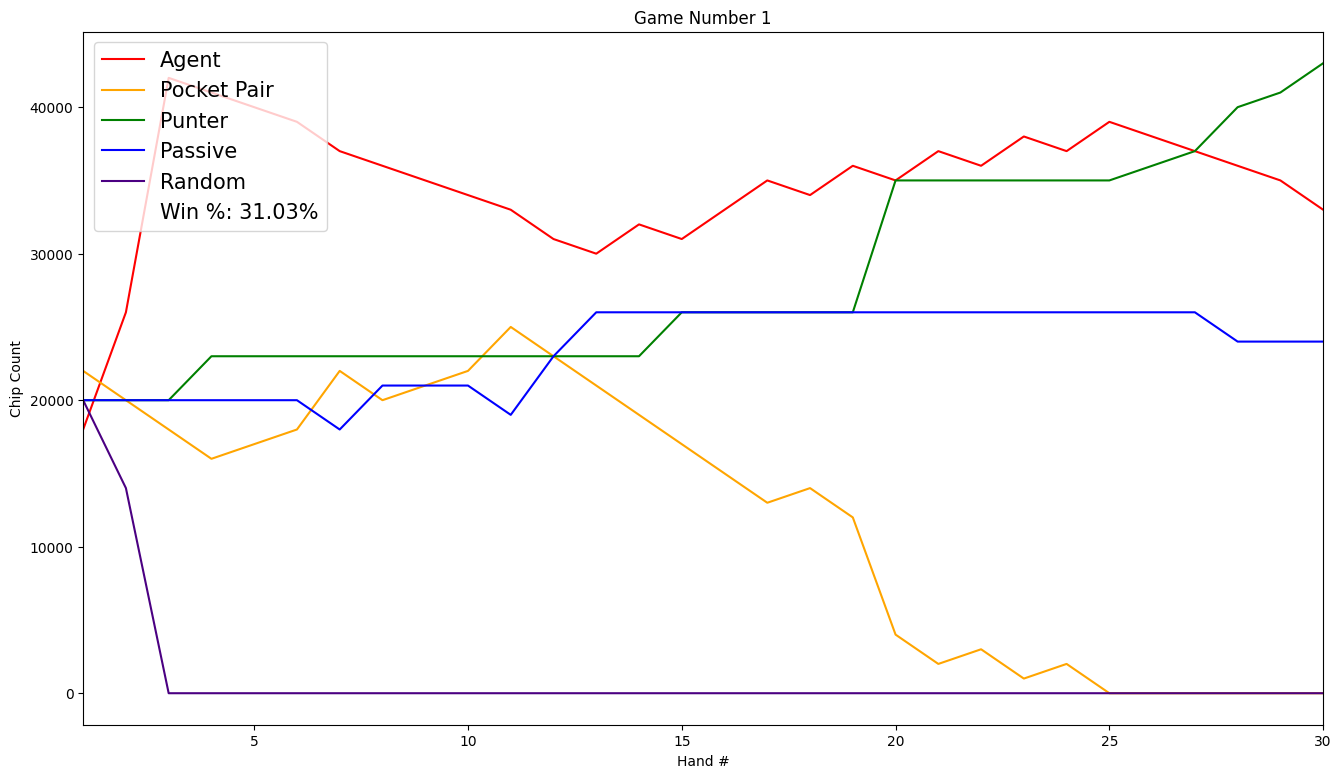

In [139]:
plotter(run_1_df, 1)

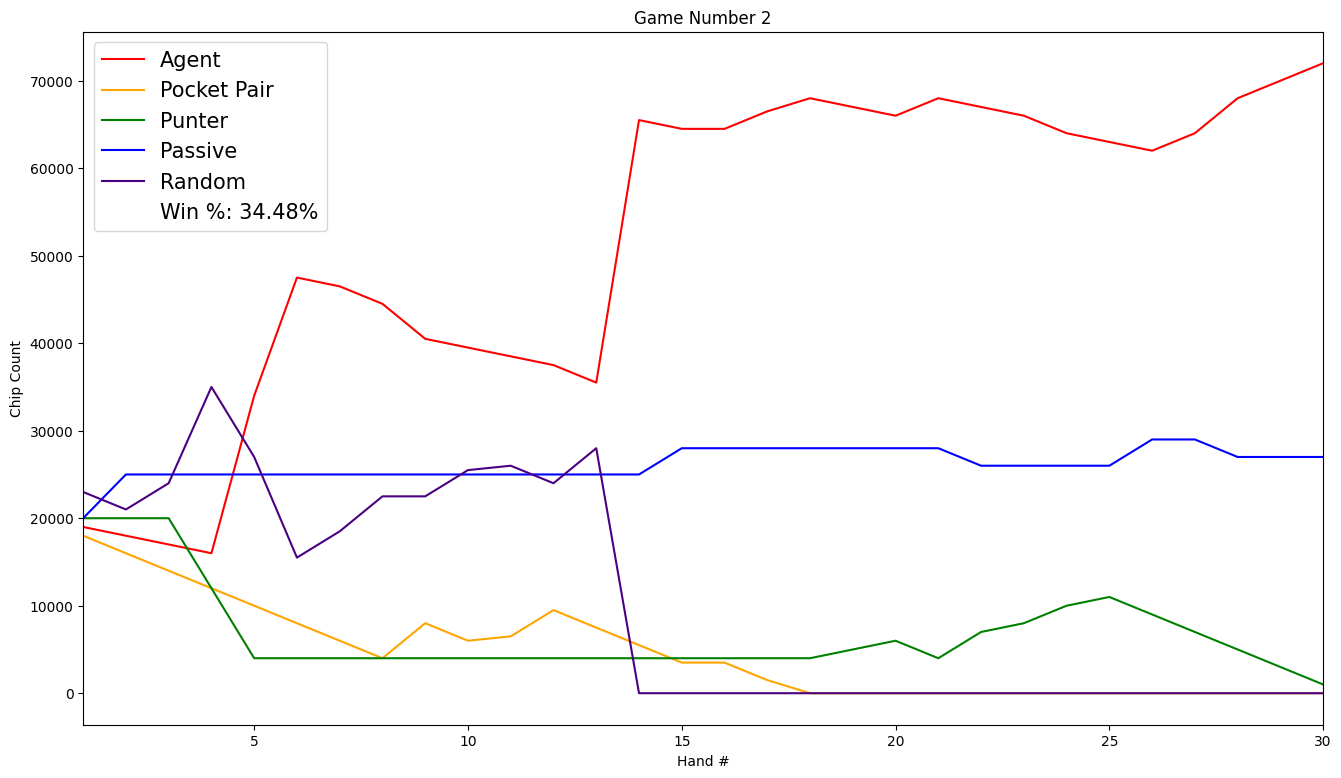

In [140]:
plotter(run_2_df, 2)

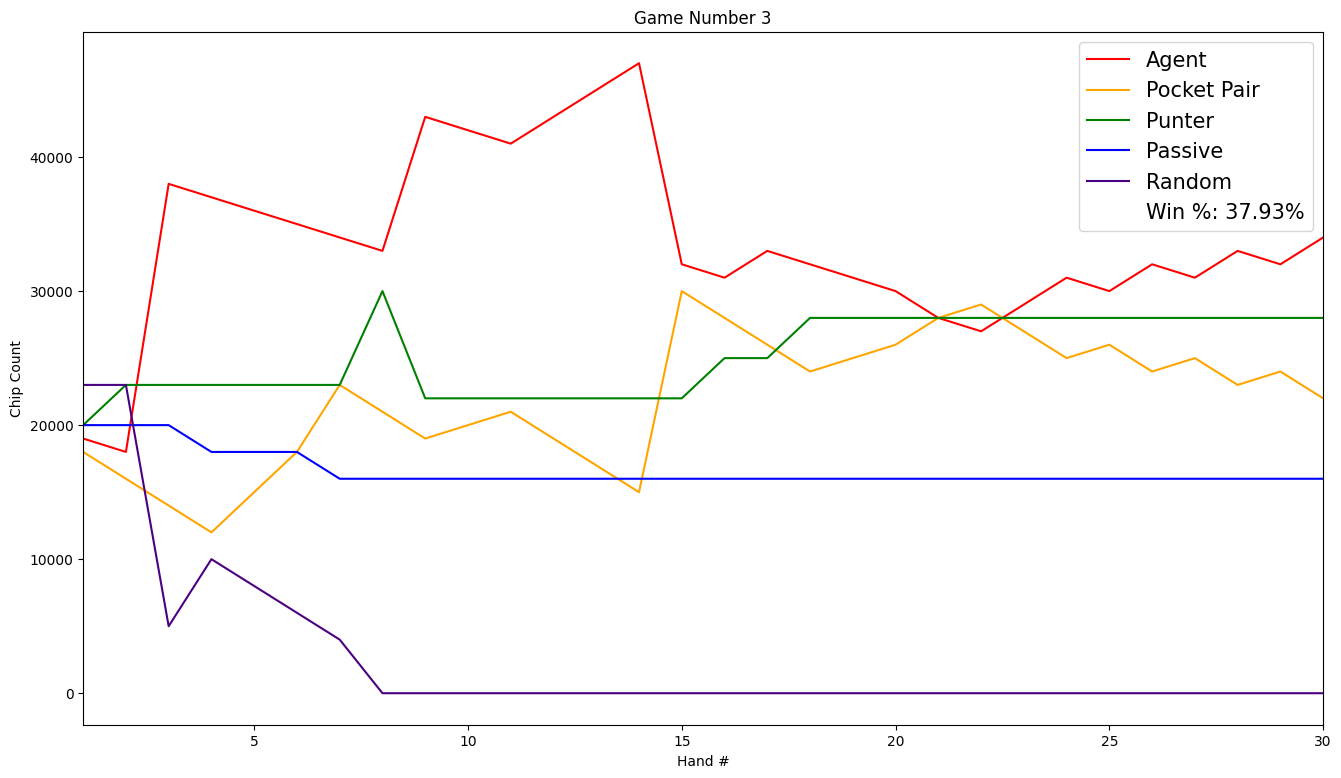

In [141]:
plotter(run_3_df, 3)

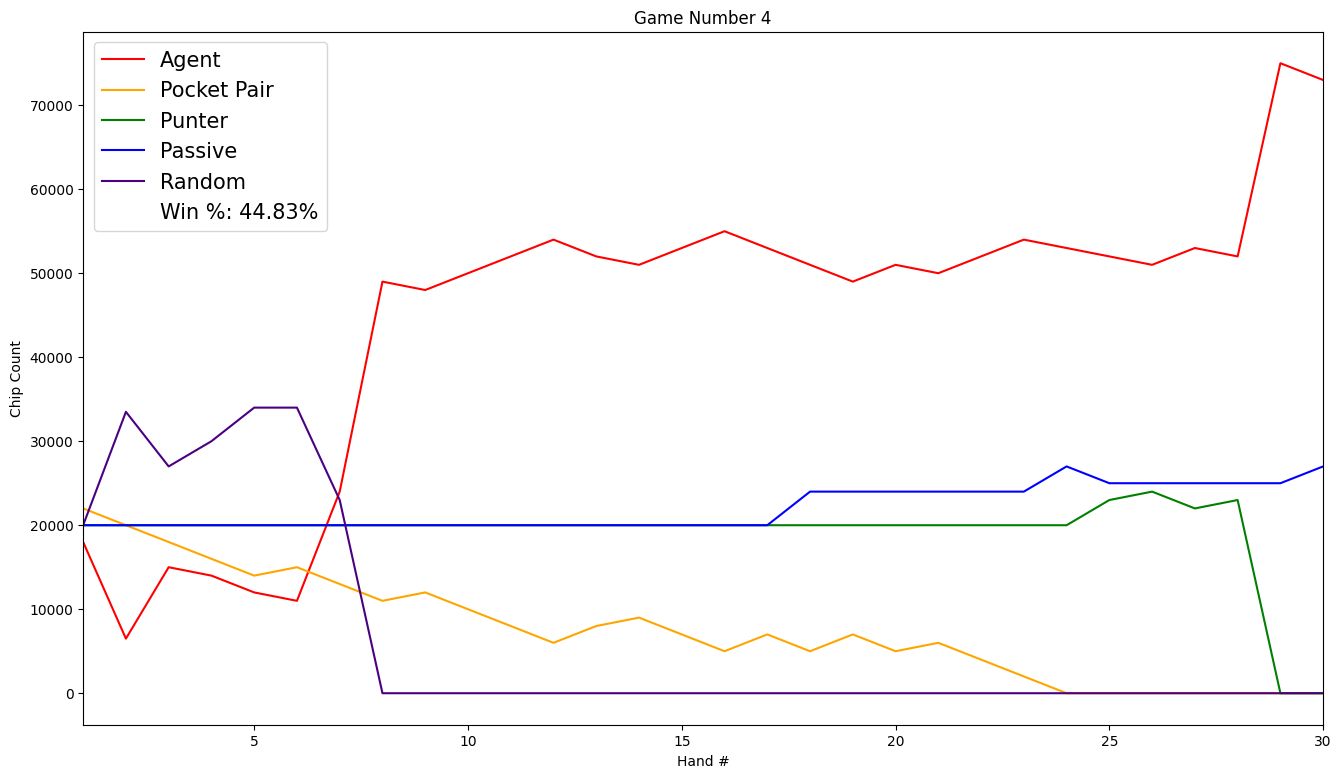

In [142]:
plotter(run_4_df, 4)

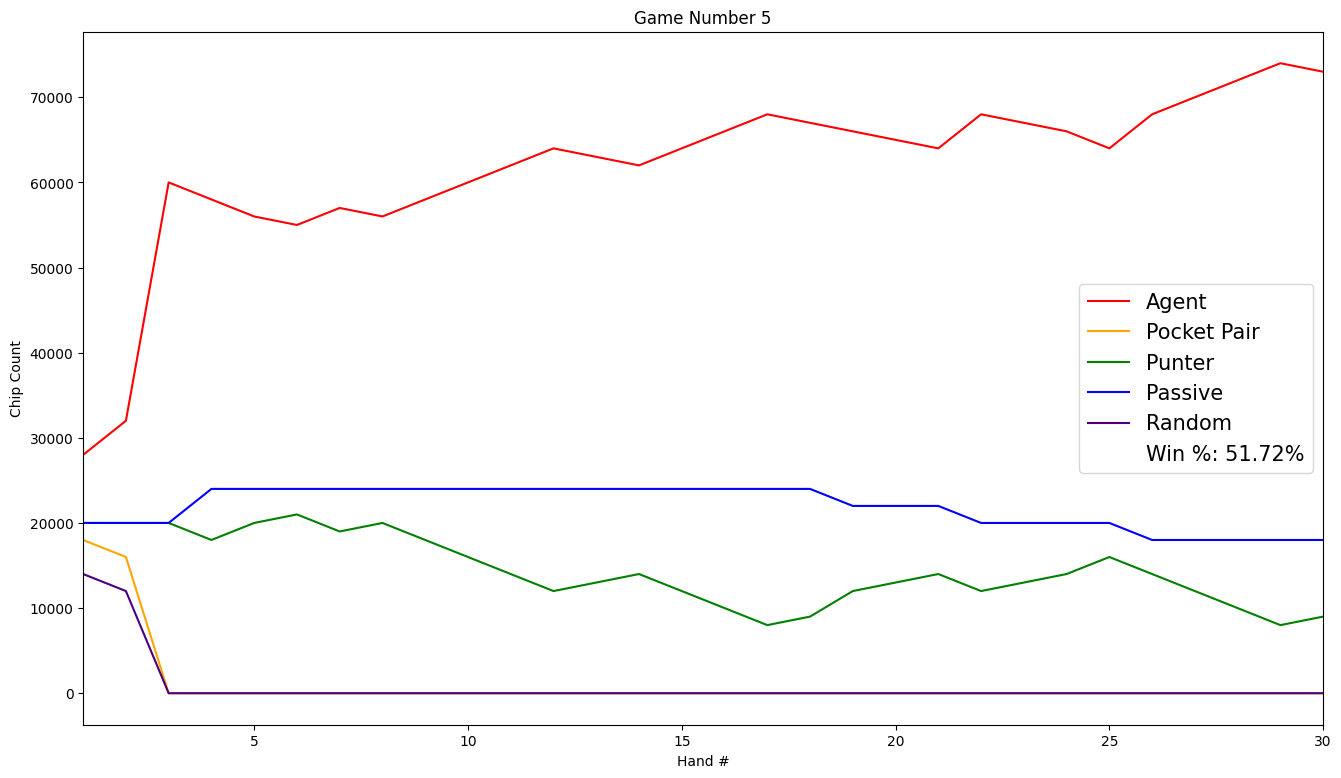

In [143]:
plotter(run_5_df, 5)

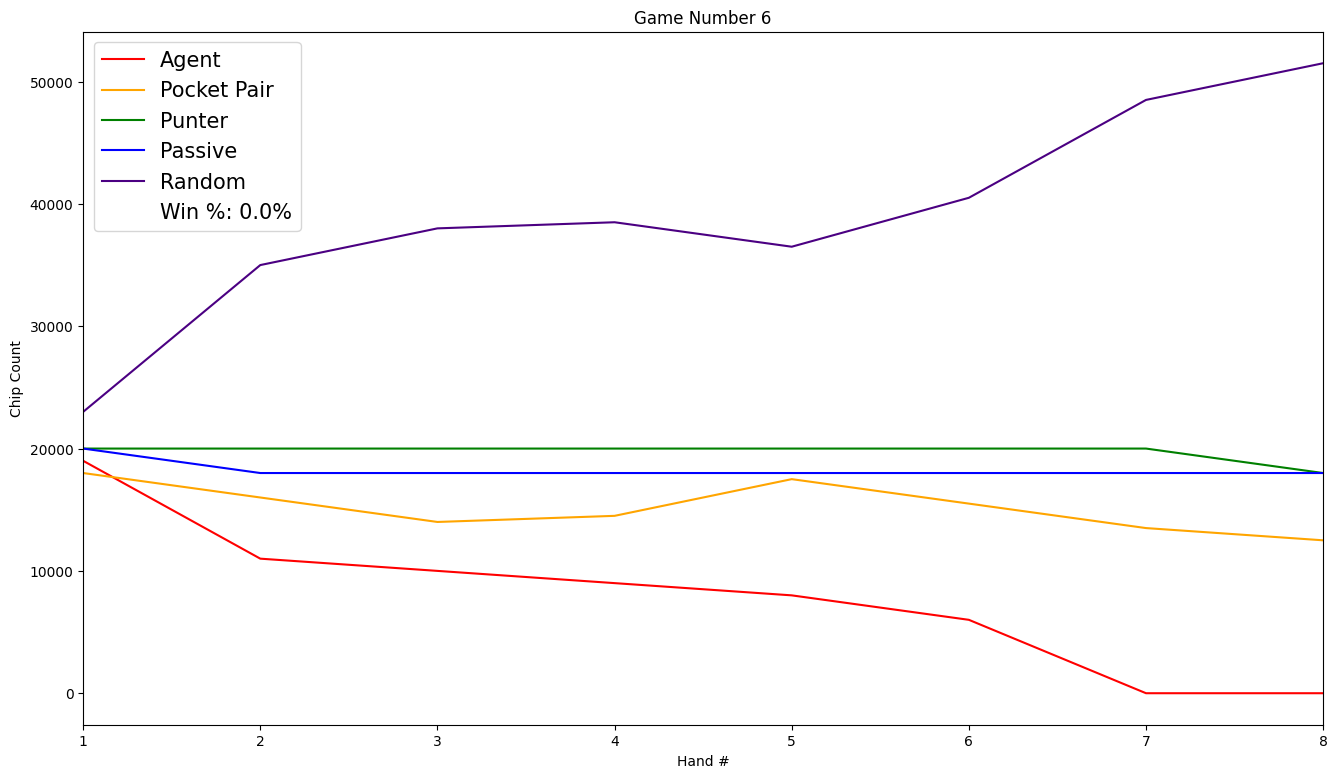

In [138]:
plotter(run_6_df, 6)

In [150]:
ends = []
for df in [run_1_df, run_2_df, run_3_df, run_4_df, run_5_df, run_6_df]:
    ends.append(df.iloc[-1, :])

In [166]:
results = pd.concat(ends, axis=1)
results.columns = ['Game 1', 'Game 2', 'Game 3', 'Game 4', 'Game 5', 'Game 6']
results['Mean'] = results.mean(axis=1)
final_chips = results.T
final_chips.map(int)

,Agent,Pocket_Pair,Punter,Passive,Random
Game 1,33000,0,43000,24000,0
Game 2,72000,0,1000,27000,0
Game 3,34000,22000,28000,16000,0
Game 4,73000,0,0,27000,0
Game 5,73000,0,9000,18000,0
Game 6,0,12500,18000,18000,51500
Mean,47500,5750,16500,21666,8583


In [170]:
final_pcts = final_chips.apply(lambda x: x/100_000 * 100, axis=0)
final_pcts.round(1)

,Agent,Pocket_Pair,Punter,Passive,Random
Game 1,33.0,0.0,43.0,24.0,0.0
Game 2,72.0,0.0,1.0,27.0,0.0
Game 3,34.0,22.0,28.0,16.0,0.0
Game 4,73.0,0.0,0.0,27.0,0.0
Game 5,73.0,0.0,9.0,18.0,0.0
Game 6,0.0,12.5,18.0,18.0,51.5
Mean,47.5,5.8,16.5,21.7,8.6
